# NFL Week 1 Analysis — Upset Analysis

This notebook evaluates whether Week 1 is unusually chaotic using three definitions of an upset:

1. **Betting-market upset** — the betting favorite loses.
2. **Subsequent-record upset** — the team with fewer wins after the game defeats the team with more future wins.
3. **Spread-based upset magnitude** — how far an upset exceeds the expected result implied by the point spread.

The analysis compares Week 1 with Weeks 2–18 and then examines unusually large Week 1 upsets.


## 1. Load prepared datasets

The data-preparation notebook creates three Parquet datasets:

- `games.parquet` — one row per game
- `team_stats.parquet` — one row per team per game
- `team_results.parquet` — one row per team per game containing win/loss results

This notebook uses the game-level data and the simplified team results.


In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import confint_proportions_2indep, proportions_ztest
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt

games = pd.read_parquet("../data/games.parquet")
team_results = pd.read_parquet("../data/team_results.parquet")

print("games:", games.shape)
print("team_results:", team_results.shape)


games: (4927, 15)
team_results: (9854, 4)


In [3]:
# Basic validation before analysis
assert games["game_id_normalized"].is_unique
assert team_results[["season", "week", "team"]].duplicated().sum() == 0

print("Unique games:", games["game_id_normalized"].nunique())
print("Week 1 games:", (games["week"] == 1).sum())
print("Missing betting-upset flags:", games["betting_upset"].isna().sum())


Unique games: 4927
Week 1 games: 303
Missing betting-upset flags: 0


## 2. Subsequent-record upset definition

A record-based upset is defined using the number of wins each team earns **after the game being evaluated**.

This avoids circularity. For example, when evaluating a Week 1 game, the Week 1 result itself is excluded, so the comparison is based on each team's Weeks 2–18 wins.

Games in which the teams finish with the same number of future wins are considered **not comparable** for this definition and are excluded from the record-based rate comparison.


In [4]:
# Calculate each team's wins AFTER each game.
future_wins = (
    team_results
    .merge(
        team_results[["season", "team", "week"]],
        on=["season", "team"],
        suffixes=("", "_game")
    )
    .query("week > week_game")
    .groupby(["season", "team", "week_game"])["wins"]
    .sum()
    .reset_index(name="future_wins")
)

games = games.merge(
    future_wins.rename(
        columns={
            "team": "team_home",
            "week_game": "week",
            "future_wins": "home_future_wins"
        }
    ),
    on=["season", "team_home", "week"],
    how="left",
    validate="many_to_one"
)

games = games.merge(
    future_wins.rename(
        columns={
            "team": "team_away",
            "week_game": "week",
            "future_wins": "away_future_wins"
        }
    ),
    on=["season", "team_away", "week"],
    how="left",
    validate="many_to_one"
)

games["future_win_difference"] = (
    games["home_future_wins"] -
    games["away_future_wins"]
).abs()

games["record_upset_future"] = (
    (
        (games["home_future_wins"] < games["away_future_wins"]) &
        (games["score_home"] > games["score_away"])
    )
    |
    (
        (games["away_future_wins"] < games["home_future_wins"]) &
        (games["score_away"] > games["score_home"])
    )
)

print("Missing home future wins:", games["home_future_wins"].isna().sum())
print("Missing away future wins:", games["away_future_wins"].isna().sum())


Missing home future wins: 304
Missing away future wins: 304


In [5]:
week1_games = games[games["week"] == 1]

week1_comparable = week1_games["future_win_difference"] > 0
week1_record_upsets = week1_games.loc[
    week1_comparable, "record_upset_future"
].sum()

week1_record_rate = (
    week1_record_upsets / week1_comparable.sum()
)

print("Week 1 record upsets:", week1_record_upsets)
print("Week 1 comparable games:", week1_comparable.sum())
print(f"Week 1 conditional record-upset rate: {week1_record_rate:.4%}")


Week 1 record upsets: 98
Week 1 comparable games: 279
Week 1 conditional record-upset rate: 35.1254%


## 3. Question 1 — Is Week 1 more chaotic?

First, compare the overall Week 1 upset rate with the rate during Weeks 2–18.

For the betting-market definition, every game is included.

For the subsequent-record definition, only games with unequal future win totals are included, because equal future records cannot identify a team as the stronger or weaker team under this definition.


In [6]:
week1_mask = games["week"] == 1
later_mask = games["week"] >= 2

# Betting-market upset comparison
week1_betting_upsets = games.loc[week1_mask, "betting_upset"].sum()
later_betting_upsets = games.loc[later_mask, "betting_upset"].sum()

week1_betting_total = week1_mask.sum()
later_betting_total = later_mask.sum()

week1_betting_rate = week1_betting_upsets / week1_betting_total
later_betting_rate = later_betting_upsets / later_betting_total

z_a, p_a = proportions_ztest(
    [week1_betting_upsets, later_betting_upsets],
    [week1_betting_total, later_betting_total]
)

ci_a_low, ci_a_high = confint_proportions_2indep(
    count1=week1_betting_upsets,
    nobs1=week1_betting_total,
    count2=later_betting_upsets,
    nobs2=later_betting_total,
    method="wald"
)

print("BETTING-MARKET UPSET")
print(f"Week 1:    {week1_betting_upsets}/{week1_betting_total} ({week1_betting_rate:.4%})")
print(f"Weeks 2–18: {later_betting_upsets}/{later_betting_total} ({later_betting_rate:.4%})")
print(f"Difference: {week1_betting_rate - later_betting_rate:.4%}")
print(f"95% CI: ({ci_a_low:.4%}, {ci_a_high:.4%})")
print(f"z-statistic: {z_a:.4f}")
print(f"p-value: {p_a:.6f}")


BETTING-MARKET UPSET
Week 1:    107/303 (35.3135%)
Weeks 2–18: 1530/4624 (33.0882%)
Difference: 2.2253%
95% CI: (-3.3245%, 7.7751%)
z-statistic: 0.7967
p-value: 0.425634


In [7]:
# Subsequent-record upset comparison
later_games = games[later_mask]

later_comparable = later_games["future_win_difference"] > 0

week1_record_total = week1_comparable.sum()
later_record_total = later_comparable.sum()

later_record_upsets = later_games.loc[
    later_comparable, "record_upset_future"
].sum()

later_record_rate = later_record_upsets / later_record_total

z_b, p_b = proportions_ztest(
    [week1_record_upsets, later_record_upsets],
    [week1_record_total, later_record_total]
)

difference_b = week1_record_rate - later_record_rate

se_b = np.sqrt(
    (week1_record_rate * (1 - week1_record_rate) / week1_record_total)
    +
    (later_record_rate * (1 - later_record_rate) / later_record_total)
)

ci_b_lower = difference_b - 1.96 * se_b
ci_b_upper = difference_b + 1.96 * se_b

print("SUBSEQUENT-RECORD UPSET")
print(f"Week 1:    {week1_record_upsets}/{week1_record_total} ({week1_record_rate:.4%})")
print(f"Weeks 2–18: {later_record_upsets}/{later_record_total} ({later_record_rate:.4%})")
print(f"Difference: {difference_b:.4%}")
print(f"95% CI: ({ci_b_lower:.4%}, {ci_b_upper:.4%})")
print(f"z-statistic: {z_b:.4f}")
print(f"p-value: {p_b:.6f}")


SUBSEQUENT-RECORD UPSET
Week 1:    98/279 (35.1254%)
Weeks 2–18: 1267/3496 (36.2414%)
Difference: -1.1160%
95% CI: (-6.9397%, 4.7077%)
z-statistic: -0.3734
p-value: 0.708883


### Interpretation

The betting-market definition measures whether Week 1 produces more **favorites losing** than later weeks.

The subsequent-record definition asks a different question: whether Week 1 produces more games in which the team that ultimately has the weaker record defeats the team that ultimately has the stronger record.

The record-based comparison uses a conditional denominator because games with equal future records are not classifiable under this definition.


## 4. Spread-based upset magnitude

The point spread provides an expected scoring margin for the favorite.

Because `spread_favorite` is stored as a negative number for the favorite, the expected favorite margin is `-spread_favorite`.

We calculate:

**spread deviation = actual favorite margin + spread**

For an upset, the negative deviation represents how much the underdog exceeded the spread expectation. This becomes the **spread upset magnitude**.


In [8]:
print("Missing spreads:", games["spread_favorite"].isna().sum())

games["spread_deviation"] = (
    games["favorite_margin"] + games["spread_favorite"]
)

games["spread_upset_magnitude"] = (
    -games["spread_deviation"]
)

games.loc[
    ~games["betting_upset"],
    "spread_upset_magnitude"
] = 0

games.loc[
    games["favorite_team"] == "PICK",
    "spread_upset_magnitude"
] = 0


Missing spreads: 0


In [9]:
week1_magnitude = games.loc[
    week1_mask & games["betting_upset"],
    "spread_upset_magnitude"
]

later_magnitude = games.loc[
    later_mask & games["betting_upset"],
    "spread_upset_magnitude"
]

t_stat, t_p = ttest_ind(
    week1_magnitude,
    later_magnitude,
    equal_var=False
)

u_stat, u_p = mannwhitneyu(
    week1_magnitude,
    later_magnitude,
    alternative="two-sided"
)

print("Week 1 upset magnitude")
print(week1_magnitude.describe())

print("\nWeeks 2–18 upset magnitude")
print(later_magnitude.describe())

print(f"\nWelch's t-test p-value: {t_p:.6f}")
print(f"Mann–Whitney U p-value: {u_p:.6f}")


Week 1 upset magnitude
count    107.000000
mean      14.158879
std        8.774856
min        2.000000
25%        8.000000
50%       11.500000
75%       18.500000
max       39.000000
Name: spread_upset_magnitude, dtype: float64

Weeks 2–18 upset magnitude
count    1530.000000
mean       13.605229
std         7.777021
min         2.000000
25%         8.000000
50%        11.500000
75%        18.000000
max        52.000000
Name: spread_upset_magnitude, dtype: float64

Welch's t-test p-value: 0.526373
Mann–Whitney U p-value: 0.770171


## 5. Large Week 1 upsets

Two thresholds are used to identify especially notable Week 1 upsets:

- **5+ point underdog wins:** the betting favorite was favored by at least 5 points and still lost.
- **4+ eventual-win gap:** the winning team finished with at least four fewer future wins than its opponent.

These definitions use different denominators, so the rates should not be interpreted as directly comparable probabilities.


In [10]:
week1_large = week1_games.copy()

week1_large["big_betting_upset"] = (
    week1_large["betting_upset"] &
    (week1_large["spread_favorite"] <= -5)
)

week1_large["big_record_upset"] = (
    week1_large["record_upset_future"] &
    (week1_large["future_win_difference"] >= 4)
)

five_plus_favorite_games = (
    week1_large["spread_favorite"] <= -5
).sum()

five_plus_upsets = week1_large["big_betting_upset"].sum()
four_plus_record_upsets = week1_large["big_record_upset"].sum()

five_plus_rate = five_plus_upsets / five_plus_favorite_games
four_plus_rate = four_plus_record_upsets / len(week1_large)

print("Week 1 games:", len(week1_large))
print("Betting-market upsets:", week1_large["betting_upset"].sum())
print("Record-based upsets:", week1_large["record_upset_future"].sum())
print()
print(f"5+ point underdog games: {five_plus_favorite_games}")
print(f"5+ point underdog wins: {five_plus_upsets}")
print(f"5+ point underdog upset rate: {five_plus_rate:.4%}")
print()
print(f"4+ eventual-win-gap upsets: {four_plus_record_upsets}")
print(f"4+ eventual-win-gap rate: {four_plus_rate:.4%}")


Week 1 games: 303
Betting-market upsets: 107
Record-based upsets: 98

5+ point underdog games: 120
5+ point underdog wins: 28
5+ point underdog upset rate: 23.3333%

4+ eventual-win-gap upsets: 35
4+ eventual-win-gap rate: 11.5512%


## 6. Visualizations

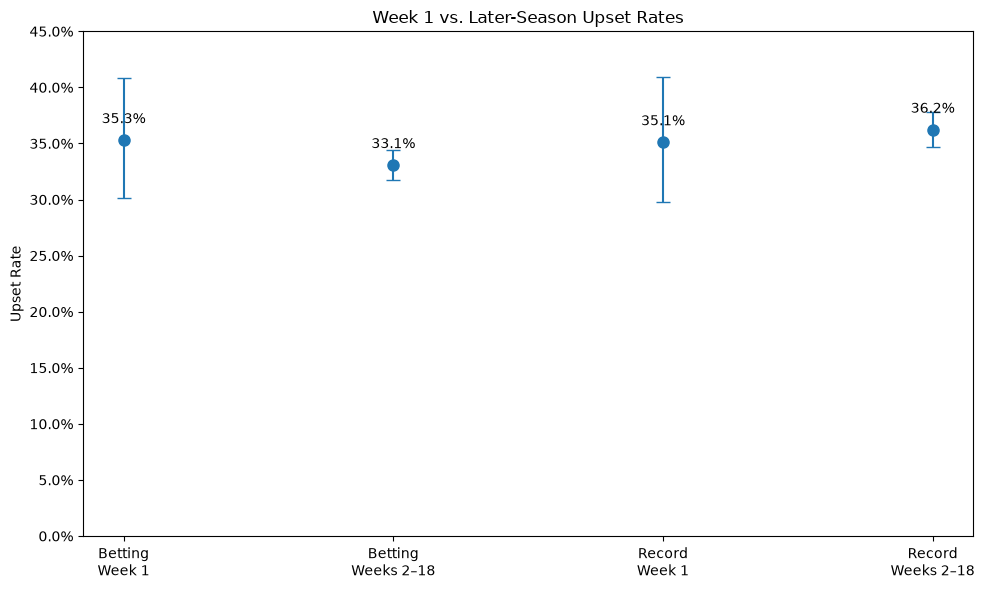

In [11]:
## 6.1 Week 1 vs. Weeks 2–18 upset rates

from statsmodels.stats.proportion import proportion_confint

# Betting-market rates
betting_counts = [
    week1_betting_upsets,
    later_betting_upsets,
]

betting_totals = [
    week1_betting_total,
    later_betting_total,
]

betting_ci = [
    proportion_confint(
        count,
        total,
        alpha=0.05,
        method="wilson"
    )
    for count, total in zip(betting_counts, betting_totals)
]

# Record-based rates
record_counts = [
    week1_record_upsets,
    later_record_upsets,
]

record_totals = [
    week1_record_total,
    later_record_total,
]

record_ci = [
    proportion_confint(
        count,
        total,
        alpha=0.05,
        method="wilson"
    )
    for count, total in zip(record_counts, record_totals)
]

labels = [
    "Betting\nWeek 1",
    "Betting\nWeeks 2–18",
    "Record\nWeek 1",
    "Record\nWeeks 2–18",
]

rates = [
    week1_betting_rate,
    later_betting_rate,
    week1_record_rate,
    later_record_rate,
]

cis = betting_ci + record_ci

lower_errors = [
    rate - ci[0]
    for rate, ci in zip(rates, cis)
]

upper_errors = [
    ci[1] - rate
    for rate, ci in zip(rates, cis)
]

plt.figure(figsize=(10, 6))

plt.errorbar(
    range(len(labels)),
    rates,
    yerr=[lower_errors, upper_errors],
    fmt="o",
    capsize=5,
    markersize=8,
)

plt.xticks(range(len(labels)), labels)
plt.ylabel("Upset Rate")
plt.title("Week 1 vs. Later-Season Upset Rates")
plt.ylim(0, 0.45)

plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)

for i, rate in enumerate(rates):
    plt.text(
        i,
        rate + 0.015,
        f"{rate:.1%}",
        ha="center",
    )

plt.tight_layout()
plt.show()

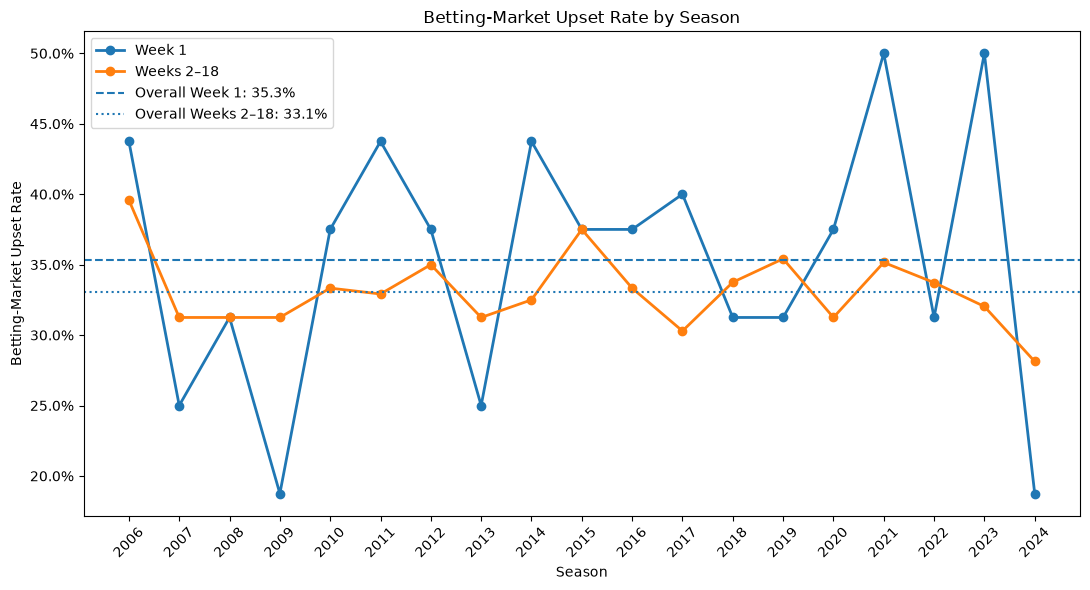

In [13]:
## 6.2 Upset rate by season

season_rates = (
    games
    .assign(
        week_1=games["week"] == 1,
        later_weeks=games["week"] >= 2
    )
    .groupby("season")
    .agg(
        week1_upset_rate=("betting_upset", lambda x: x[games.loc[x.index, "week"] == 1].mean()),
        later_upset_rate=("betting_upset", lambda x: x[games.loc[x.index, "week"] >= 2].mean()),
    )
    .reset_index()
)

# Overall rates for reference
overall_week1_rate = games.loc[
    games["week"] == 1,
    "betting_upset"
].mean()

overall_later_rate = games.loc[
    games["week"] >= 2,
    "betting_upset"
].mean()

plt.figure(figsize=(11, 6))

plt.plot(
    season_rates["season"],
    season_rates["week1_upset_rate"],
    marker="o",
    linewidth=2,
    label="Week 1"
)

plt.plot(
    season_rates["season"],
    season_rates["later_upset_rate"],
    marker="o",
    linewidth=2,
    label="Weeks 2–18"
)

plt.axhline(
    overall_week1_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall Week 1: {overall_week1_rate:.1%}"
)

plt.axhline(
    overall_later_rate,
    linestyle=":",
    linewidth=1.5,
    label=f"Overall Weeks 2–18: {overall_later_rate:.1%}"
)

plt.xlabel("Season")
plt.ylabel("Betting-Market Upset Rate")
plt.title("Betting-Market Upset Rate by Season")
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)

plt.xticks(
    season_rates["season"],
    rotation=45
)

plt.legend()
plt.tight_layout()
plt.show()

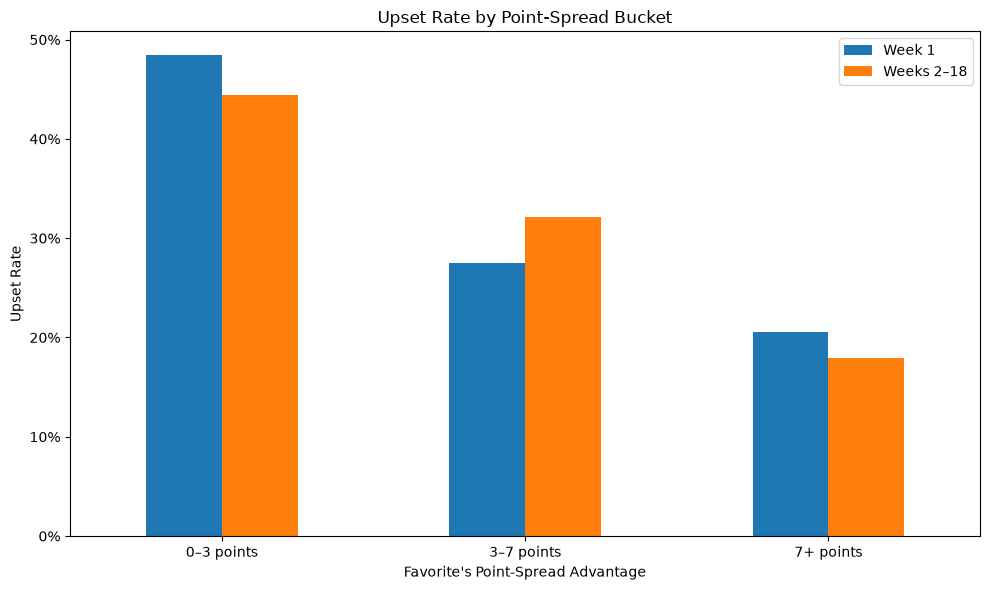

In [19]:
## 6.3 Upset rate by point-spread bucket

spread_analysis = games[
    (games["favorite_team"] != "PICK")
    & games["spread_favorite"].notna()
].copy()

# Convert negative favorite spread into favorite's point advantage
spread_analysis["favorite_spread_points"] = (
    -spread_analysis["spread_favorite"]
)

# Create spread buckets
spread_analysis["spread_bucket"] = pd.cut(
    spread_analysis["favorite_spread_points"],
    bins=[0, 3, 7, np.inf],
    labels=[
        "0–3 points",
        "3–7 points",
        "7+ points",
    ],
    include_lowest=True,
)

# Create analysis period directly from the existing week column
spread_analysis["period"] = np.where(
    spread_analysis["week"] == 1,
    "Week 1",
    "Weeks 2–18",
)

# Calculate upset rates
spread_rates = (
    spread_analysis
    .groupby(
        ["spread_bucket", "period"],
        observed=False,
    )
    .agg(
        upset_rate=("betting_upset", "mean"),
        games=("betting_upset", "size"),
        upsets=("betting_upset", "sum"),
    )
    .reset_index()
)

# Reshape for plotting
plot_data = spread_rates.pivot(
    index="spread_bucket",
    columns="period",
    values="upset_rate",
)

plot_data = plot_data[
    ["Week 1", "Weeks 2–18"]
]

# Plot
ax = plot_data.plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_xlabel("Favorite's Point-Spread Advantage")
ax.set_ylabel("Upset Rate")
ax.set_title("Upset Rate by Point-Spread Bucket")

ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)

plt.xticks(rotation=0)
plt.legend(title="")
plt.tight_layout()
plt.show()

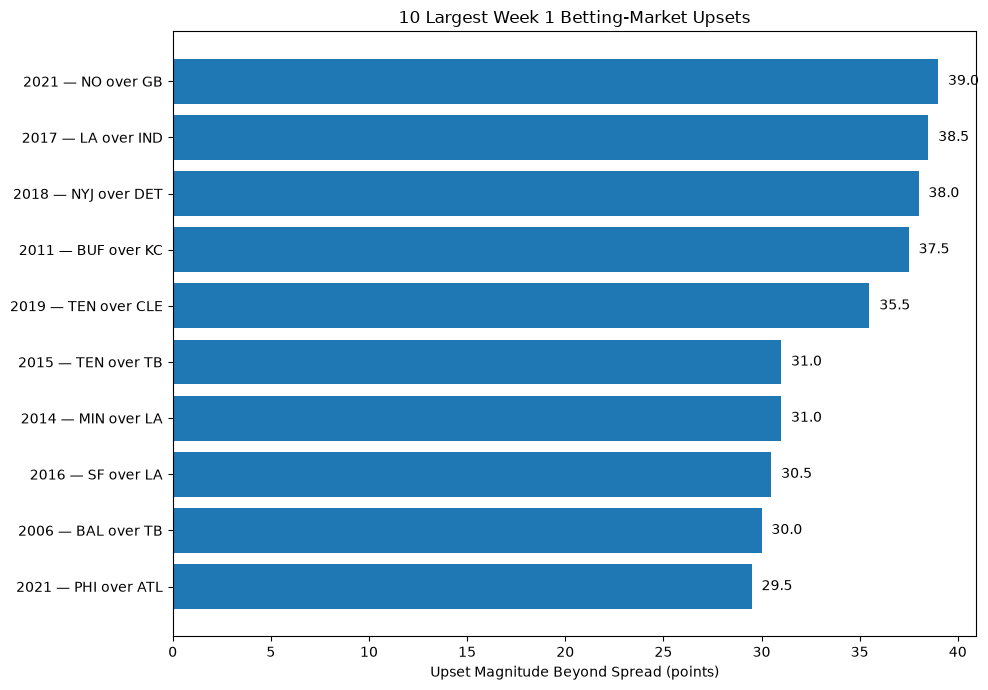

In [ ]:
## 6.4 Largest Week 1 upsets

top_upsets = (
    games.loc[
        (games["week"] == 1)
        & games["betting_upset"]
    ]
    .copy()
)

top_upsets["underdog_team"] = np.where(
    top_upsets["favorite_team"] == top_upsets["team_home"],
    top_upsets["team_away"],
    top_upsets["team_home"],
)

top_upsets["season_label"] = (
    top_upsets["season"].astype(str)
    + " — "
    + top_upsets["underdog_team"]
    + " over "
    + top_upsets["favorite_team"]
)

top_upsets = (
    top_upsets
    .sort_values(
        "spread_upset_magnitude",
        ascending=False,
    )
    .head(10)
    .sort_values(
        "spread_upset_magnitude"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_upsets["season_label"],
    top_upsets["spread_upset_magnitude"],
)

plt.xlabel("Upset Magnitude Beyond Spread (points)")
plt.ylabel("")
plt.title("10 Largest Week 1 Betting-Market Upsets")

for i, value in enumerate(
    top_upsets["spread_upset_magnitude"]
):
    plt.text(
        value + 0.5,
        i,
        f"{value:.1f}",
        va="center",
    )

plt.tight_layout()
plt.show()

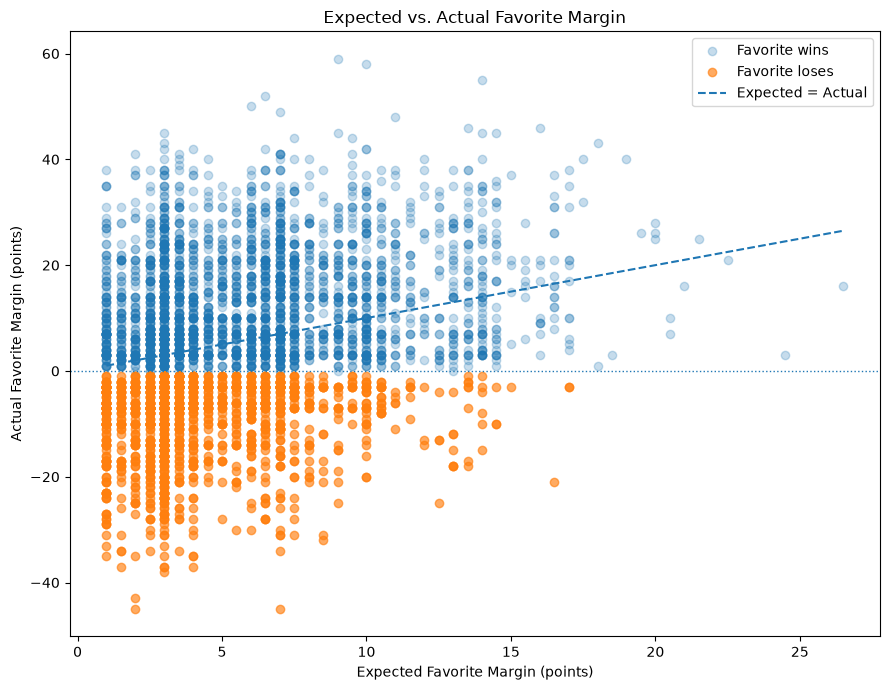

In [ ]:
## 6.5 Expected vs. actual favorite margin

plot_games = games[
    games["favorite_team"] != "PICK"
].copy()

plot_games["expected_margin"] = (
    -plot_games["spread_favorite"]
)

plt.figure(figsize=(9, 7))

normal_games = plot_games[
    ~plot_games["betting_upset"]
]

upset_games = plot_games[
    plot_games["betting_upset"]
]

plt.scatter(
    normal_games["expected_margin"],
    normal_games["favorite_margin"],
    alpha=0.25,
    label="Favorite wins",
)

plt.scatter(
    upset_games["expected_margin"],
    upset_games["favorite_margin"],
    alpha=0.65,
    label="Favorite loses",
)

# Perfect-calibration line
x_min = plot_games["expected_margin"].min()
x_max = plot_games["expected_margin"].max()

plt.plot(
    [x_min, x_max],
    [x_min, x_max],
    linestyle="--",
    linewidth=1.5,
    label="Expected = Actual",
)

plt.axhline(
    0,
    linestyle=":",
    linewidth=1,
)

plt.xlabel("Expected Favorite Margin (points)")
plt.ylabel("Actual Favorite Margin (points)")
plt.title("Expected vs. Actual Favorite Margin")
plt.legend()

plt.tight_layout()
plt.show()

## Q1 Takeaway

Week 1 produces an upset rate of approximately **35%** under both the betting-market and subsequent-record definitions.

The betting-market rate is **35.31%** of all Week 1 games, while the subsequent-record rate is **35.13%** among comparable games.

The Week 1 vs. Weeks 2–18 statistical comparison for the subsequent-record definition does **not** provide evidence of a meaningful difference.

The spread-based analysis also finds no statistically significant difference in upset magnitude between Week 1 and later weeks.

Overall, Week 1 does not appear to be dramatically more chaotic than the rest of the regular season based on these upset measures.
